# Fit to observed

## Using the only the density map output

### Loading model

In [ ]:
import torch
import torch.nn as nn
from modelsImplementation import CerealNet

# Check if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_shape = (3, 224, 224)

modelName = "CerealNet_VGG16"

model = CerealNet.CerealNet("VGG16").to(device)

model.load_state_dict(torch.load(f'models/{modelName}.pt'))

### Iterating over the images

In [ ]:
import os
import torch
import numpy as np
from torchvision import transforms
import pandas as pd
from PIL import Image
from tqdm import tqdm

whole_folder = "./data/counted_images"

whole_transform = transforms.Compose([
    transforms.ToTensor(),
]
)

pred_array = []

model.eval()
for file in tqdm(os.listdir(whole_folder), "Getting predictions from images"):
    image = Image.open(os.path.join(whole_folder, file)).convert('RGB')
    x_image = whole_transform(image).to(device).unsqueeze(0)
    with torch.no_grad():
        y_pred = model(x_image)
    probability_map = transforms.ToPILImage()(y_pred.cpu().squeeze())
    prediction = np.array(probability_map, dtype=np.float32)
    prediction = np.sum(prediction) / 10000
    pred_array.append(prediction)

100%|██████████| 594/594 [00:11<00:00, 51.94it/s]


### Creating the Dataframe

In [ ]:
ground_truth = pd.read_csv("data/data.csv")

dataset = pd.DataFrame({'Predicted': pred_array})
df_grouped = dataset.groupby(dataset.index // 3).sum().join(ground_truth)
df_grouped.drop('Picture', axis=1)
df_grouped.rename(columns={'GrainCount': 'Observed'})

print(df_grouped)

csv_filename = f"results/Fit_to_observed_{modelName}.csv"
df_grouped.to_csv(csv_filename, index=False, sep=',')
print(f"CSV file '{csv_filename}' has been created.")

     Predicted  Picture  GrainCount
0     766.0940    90652        2164
1     718.0508    90830        2164
2    1062.4112    91143        3138
3    1076.3204    91241        3138
4    1005.2548    91418        2929
..         ...      ...         ...
193   728.7312   111958        1526
194   702.2080   112023        2171
195   737.0472   112042        2171
196   683.8696   112116        1562
197   556.2264   112128        1562

[198 rows x 3 columns]
CSV file 'results/Fit_to_observed_CerealNet_VGG16.csv' has been created.


## Using Machine Learning models (Combining image and DM output)

### Preparing the data

In [ ]:
from glob import glob
from PIL import Image
from tqdm import tqdm
import os

def load_and_stack_images(image_dir):
    # Get all image paths and group by prefix
    image_paths = sorted(glob(os.path.join(image_dir, '*.png')))
    
    # Create dictionary to group images by their prefix
    image_groups = {}
    print("------- Loading Images -------")
    for path in tqdm(image_paths):
        base_name = os.path.basename(path)
        prefix = base_name.split('_')[0]
        if prefix not in image_groups:
            image_groups[prefix] = []
        image_groups[prefix].append(path)
    
    # Process each group
    stacked_images = []
    print("------- Combining images -------")
    for prefix, paths in tqdm(image_groups.items()):
        # Ensure we have exactly 3 images per group
        if len(paths) != 3:
            raise ValueError(f"Expected 3 images for prefix {prefix}, found {len(paths)}")
        
        # Load and stack images vertically
        images = [Image.open(p) for p in sorted(paths)]  # Sort to ensure _0, _1, _2 order
        widths, heights = zip(*(i.size for i in images))
        
        # Stack vertically
        total_height = sum(heights)
        max_width = max(widths)
        stacked = Image.new('RGB', (max_width, total_height))
        
        y_offset = 0
        for img in images:
            stacked.paste(img, (0, y_offset))
            y_offset += img.size[1]
        
        # Resize to 224x224
        stacked = stacked.resize((224, 224))
        stacked_images.append(stacked)

    return stacked_images

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

def extract_features_with_pca(stacked_images, n_components=50):
    # Convert images to numpy arrays and flatten
    image_arrays = [np.array(img).flatten() for img in stacked_images]
    image_arrays = np.array(image_arrays)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    features = pca.fit_transform(image_arrays)
    
    return features

In [ ]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Extracting features from images
image_dir = 'data/counted_images'
stacked_images = load_and_stack_images(image_dir)
image_features = extract_features_with_pca(stacked_images, n_components=50)

# Getting the outputs from density maps
df = pd.read_csv("results/Fit_to_observed_CerealNet_VGG16.csv")
numeric_features = df['Predicted'].to_numpy()

# Combine images and density maps counts
print("------- Combining images and density map outputs -------")
X_combined = np.column_stack([image_features, numeric_features])

# Define the Observed values
targets = df['GrainCount'].to_numpy()

------- Loading Images -------


100%|██████████| 594/594 [00:00<00:00, 295331.50it/s]


------- Combining images -------


100%|██████████| 198/198 [00:01<00:00, 110.95it/s]


------- Combining images and density map outputs -------


### Training loader

In [ ]:
from tqdm.auto import tqdm
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import cross_val_score

def grid_search_with_progress(model, param_grid, X, y, cv=5):
    """Custom GridSearch implementation with tqdm progress tracking"""
    param_list = list(ParameterGrid(param_grid))
    results = []
    
    with tqdm(total=len(param_list)*cv, desc="GridSearch Progress") as pbar:
        for params in param_list:
            model.set_params(**params)
            scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
            
            # Store results
            results.append({
                'params': params,
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
                'cv_scores': scores
            })
            pbar.update(cv)
    
    # Find best parameters
    best_result = max(results, key=lambda x: x['mean_score'])
    best_params = best_result['params']
    best_score = best_result['mean_score']
    
    # Refit best model on full data
    best_model = model.set_params(**best_params)
    best_model.fit(X, y)
    
    return best_model, best_params, best_score, results

c:\Users\gnoceras\Documents\CV_Yield_Tool\modelfunctions\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### SVR

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print("------- Splitting Data -------")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, targets, test_size=0.2, random_state=42
)

------- Splitting Data -------


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from joblib import dump

param_grid = {
    'C': [1, 10, 20],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto']
}

svr = SVR(kernel='rbf')
model, best_params, best_score, all_results = grid_search_with_progress(
    svr, param_grid, X_train, y_train, cv=5
)

print(f"Best parameters: {best_params}")

# Save the trained SVR model and scaler
dump(model, 'models/svr_model.joblib')
dump(scaler, 'models/scaler.joblib')

GridSearch Progress: 100%|██████████| 90/90 [00:00<00:00, 161.11it/s]

Best parameters: {'C': 20, 'epsilon': 0.5, 'gamma': 'auto'}


['models/scaler.joblib']

### XGBoost

In [ ]:
# Split data
print("------- Splitting Data -------")
X_train, X_test, y_train, y_test = train_test_split(
        X_combined, targets, test_size=0.2, random_state=666
    )

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 250, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.001]
}

# Initialize the XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Perform grid search with cross-validation
model, best_params, best_score, all_results = grid_search_with_progress(
    xgb_model, param_grid, X_train, y_train, cv=5
)

print(f"Best parameters: {best_params}")

model.save_model('models/xgboost_stacked_pca_model.json')

GridSearch Progress: 100%|██████████| 135/135 [00:59<00:00,  2.28it/s]


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}


### Deep Learning

#### Prepare Data

In [4]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import numpy as np
import os
from glob import glob

class ImageNumericDataset(Dataset):
    def __init__(self, image_dir, csv_path):
        """
        Args:
            image_dir: Directory with images (XXXX_0.png, XXXX_1.png, XXXX_2.png)
            csv_path: CSV with predicted features and targets
            transform: Optional torchvision transforms
        """
        self.image_dir = image_dir
        self.df = pd.read_csv(csv_path)
        self.transform = self.default_transform()
        
        # Group image paths by prefix
        self.image_groups = self._group_images()

        self.samples = self._prepare_samples()

    def _group_images(self):
        """Group images by their prefix (XXXX)"""
        image_paths = sorted(glob(os.path.join(self.image_dir, '*.png')))

        groups = {}
        for path in image_paths:
            base = os.path.basename(path)
            prefix = base.split('_')[0]
            if prefix not in groups:
                groups[prefix] = []
            groups[prefix].append(path)

        return groups

    def _prepare_samples(self):
        """Match image groups with dataframe entries"""
        samples = []
        
        # Convert DataFrame 'Picture' column to strings and strip any whitespace
        df_pictures = self.df['Picture'].astype(str).str.strip().values
        
        for prefix in self.image_groups.keys():
            # Check if prefix exists in DataFrame (with and without leading zeros)
            if (prefix in df_pictures) or str(int(prefix)) in df_pictures:
                samples.append(prefix)
            else:
                print(f"[Debug] No match for prefix: {prefix}")

        return samples

    def default_transform(self):
        """Default transforms for ResNet18"""
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def _load_and_stack_images(self, paths):
        """Load and vertically stack 3 images"""
        images = [Image.open(p) for p in sorted(paths)]
        widths, heights = zip(*(i.size for i in images))
        
        # Stack vertically
        stacked = Image.new('RGB', (max(widths), sum(heights)))
        y_offset = 0
        for img in images:
            stacked.paste(img, (0, y_offset))
            y_offset += img.size[1]
        
        # Resize to 224x224
        return stacked.resize((224, 224))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        prefix = self.samples[idx]
        
        # Load and transform image
        img_paths = self.image_groups[prefix]
        image = self._load_and_stack_images(img_paths)
        image = self.transform(image)
        
        # Get predicted features (excluding target)
        predicted_features = self.df[self.df['Picture'] ==  int(prefix)].drop(columns=['Picture', 'GrainCount']).values[0]
        predicted_features = torch.FloatTensor(predicted_features)
        
        # Get target
        target = self.df[self.df['Picture'] ==  int(prefix)]['GrainCount'].values[0]
        target = torch.FloatTensor([target])
        
        return {
            'image': image,
            'predicted': predicted_features,
            'observed': target
        }
    
    def print_sample_details(self, idx):
        """Print detailed information about a specific sample"""
        sample = self.__getitem__(idx)
        prefix = self.samples[idx]
        
        print(f"\n=== Debug Sample {idx} ({prefix}) ===")
        print(f"Image paths: {self.image_groups[prefix]}")
        print(f"Image tensor shape: {sample['image'].shape}")
        print(f"Image tensor range: {sample['image'].min():.3f} - {sample['image'].max():.3f}")
        print(f"predicted features: {sample['predicted']}")
        print(f"predicted features shape: {sample['predicted'].shape}")
        print(f"Target value: {sample['observed']}")
        
        # Show matching row from DataFrame
        df_row = self.df[self.df['Picture'] == prefix]
        print("\nMatching DataFrame row:")
        print(df_row.to_string(index=False))
    
    def summarize_data(self):
        """Print summary statistics for all data"""
        print("\n=== Dataset Summary ===")
        print(f"Total samples: {len(self)}")
        
        # Check predicted features
        if len(self) > 0:
            sample = self.__getitem__(0)
            print(f"\npredicted features per sample: {sample['predicted'].shape[0]}")
            print(f"Target shape: {sample['observed'].shape}")
            
            # Collect all predicted features and observeds
            all_predicted = []
            all_observeds = []
            for i in range(min(100, len(self))):  # Check first 100 samples
                sample = self.__getitem__(i)
                all_predicted.append(sample['predicted'].numpy())
                all_observeds.append(sample['observed'].item())
            
            print("\npredicted Features Stats:")
            print(f"Min: {np.min(all_predicted):.4f}")
            print(f"Mean: {np.mean(all_predicted):.4f}")
            print(f"Max: {np.max(all_predicted):.4f}")
            
            print("\nobserved Values Stats:")
            print(f"Min: {np.min(all_observeds):.4f}")
            print(f"Mean: {np.mean(all_observeds):.4f}")
            print(f"Max: {np.max(all_observeds):.4f}")
            print(f"Unique values: {np.unique(all_observeds)}")

In [5]:
from torch.utils.data import Dataset, DataLoader
import torch

def prepare_dataloaders(image_dir, csv_path, batch_size=32, test_size=0.2):
    
    """Create train and test dataloaders"""
    full_dataset = ImageNumericDataset(image_dir, csv_path)
    
    # Split dataset
    train_size = int((1 - test_size) * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, test_size])
    
    print(f"Train size: {len(train_dataset)}")
    print(f"Test size: {len(test_dataset)}")
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

In [6]:
IMAGE_DIR = 'data/counted_images'
CSV_PATH = 'results/Fit_to_observed_CerealNet_VGG16.csv'
BATCH_SIZE = 32

full_dataset = ImageNumericDataset(IMAGE_DIR, CSV_PATH)

# Prepare dataloaders
train_loader, test_loader = prepare_dataloaders(
    image_dir=IMAGE_DIR,
    csv_path=CSV_PATH,
    batch_size=BATCH_SIZE
)

# Example: Inspect one batch
batch = next(iter(train_loader))
print("Image batch shape:", batch['image'].shape)  # Should be [32, 3, 224, 224]
print("Numeric features shape:", batch['predicted'].shape)  # [32, n_features]
print("Target shape:", batch['observed'].shape)  # [32, 1]

Train size: 158
Test size: 40
Image batch shape: torch.Size([32, 3, 224, 224])
Numeric features shape: torch.Size([32, 1])
Target shape: torch.Size([32, 1])


#### ResNet18

In [8]:
import torch.nn as nn
import torchvision.models as models

class ResNet18WithNumeric(nn.Module):
    def __init__(self, num_numeric_features, num_outputs=1):
        super().__init__()
        # Pretrained ResNet50
        self.resnet = models.resnet18(weights = 'DEFAULT')
        
        # Remove final fully connected layer
        self.resnet_features = nn.Sequential(*list(self.resnet.children())[:-1])
        
        # Numeric features pathway
        self.numeric_fc = nn.Linear(num_numeric_features, 128)
        
        # Combined classifier
        self.combined_fc = nn.Sequential(
            nn.Linear(512 + 128, 256),  # 512 from ResNet avg pool, 128 from numeric
            nn.ReLU(),
            nn.Linear(256, num_outputs)
        )
    
    def forward(self, image, numeric):
        # Image features
        img_features = self.resnet_features(image)
        img_features = img_features.view(img_features.size(0), -1)  # Flatten
        
        # Numeric features
        num_features = self.numeric_fc(numeric)
        
        # Concatenate and predict
        combined = torch.cat([img_features, num_features], dim=1)
        return self.combined_fc(combined)

#### VGG16

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import vgg16
import torch.nn.functional as F

class VGG16WithNumeric(nn.Module):
    def __init__(self, num_numeric_features, num_outputs=1, pretrained=True):
        super(VGG16WithNumeric, self).__init__()
        
        # Load pretrained VGG16
        vgg = vgg16(weights='DEFAULT')
        
        # Extract feature layers (remove classifier)
        self.features = vgg.features
        
        # Freeze early layers (optional)
        for param in self.features[:24].parameters():  # Freeze first 4 blocks
            param.requires_grad = False
            
        # Image feature adapter
        self.image_features_adapter = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)),  # VGG16's original classifier expects 7x7 features
            nn.Flatten()
        )
        
        # Numeric features pathway
        self.numeric_fc = nn.Sequential(
            nn.Linear(num_numeric_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        
        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(25088 + 256, 4096),  # 25088 = 512*7*7 (VGG16 features)
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_outputs)
        )
        
        # Initialize weights for new layers
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, image, numeric):
        # Extract image features
        img_features = self.features(image)
        img_features = self.image_features_adapter(img_features)
        
        # Process numeric features
        num_features = self.numeric_fc(numeric)
        
        # Combine features
        combined = torch.cat([img_features, num_features], dim=1)
        return self.classifier(combined)

#### MobileNetv4

In [15]:
import torch
import torch.nn as nn
import timm

class MobileV4WithNumeric(nn.Module):
    def __init__(self, num_numeric_features, num_outputs=1):
        super(MobileV4WithNumeric, self).__init__()
        
        model = timm.create_model('mobilenetv4_conv_aa_large.e230_r448_in12k_ft_in1k', pretrained=True).to(device)
            
        self.mobileNetFeatures = nn.Sequential(*list(model.children())[:-1])
        
        # Numeric features pathway
        self.numeric_fc = nn.Sequential(
            nn.Linear(num_numeric_features, 128),
        )
        
        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_outputs)
        )

    def forward(self, image, numeric):
        # Extract image features
        img_features = self.mobileNetFeatures(image)
        
        # Process numeric features
        num_features = self.numeric_fc(numeric)
        
        # Combine features
        combined = torch.cat([img_features, num_features], dim=1)
        return self.classifier(combined)

#### GNet

In [1]:
import torch
import torch.nn as nn
import timm
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        out = avg_out + max_out
        return out.view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)

class GNet(nn.Module):
    def __init__(self, num_numeric_features, num_outputs=1):
        super(GNet, self).__init__()
    

        model = timm.create_model('mobilenetv4_conv_aa_large.e230_r448_in12k_ft_in1k', pretrained=True).to(device)
        #model = timm.create_model('lcnet_050.ra2_in1k', pretrained=True).to(device)
        self.features = nn.Sequential(*list(model.children())[:-2])
        
        # Attention mechanisms
        self.channel_attention = ChannelAttention(1280)
        self.spatial_attention = SpatialAttention()
        
        # Numeric features pathway
        self.numeric_fc = nn.Sequential(
            nn.Linear(num_numeric_features, 128),
        )
        
        # Combined classifier
        self.combined_fc = nn.Sequential(
            nn.Linear(1280 + 128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_outputs)
        )
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, image, numeric):
        # Extract image features
        x = self.features(image)
        
        # Apply attention mechanisms
        ca = self.channel_attention(x)
        x = x * ca
        
        sa = self.spatial_attention(x)
        x = x * sa
        
        # Global average pooling
        img_features = F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1)
        
        # Process numeric features
        num_features = self.numeric_fc(numeric)
        
        # Combine features
        combined = torch.cat([img_features, num_features], dim=1)
        return self.combined_fc(combined)

c:\Users\gnoceras\Documents\CV_Yield_Tool\modelfunctions\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Train

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelName = "GNet"

#model = ResNet18WithNumeric(num_numeric_features = 1)
#model = VGG16WithNumeric(num_numeric_features = 1)
#model = MobileV4WithNumeric(num_numeric_features = 1)
model = GNet(num_numeric_features=1)

model.to(device)

print(model)

GNet(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNormAct2d(
      24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Sequential(
        (0): EdgeResidual(
          (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (aa): AvgPool2d(kernel_size=2, stride=2, padding=0)
          (se): Identity()
          (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Identity()
          )

In [3]:
x = torch.randn(1, 3, 224, 224).to(device)
numeric = torch.randn(1, 1).to(device)
model.eval()
output = model(x, numeric).to(device)
print(output.shape)

torch.Size([1, 1])


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_model(model, train_loader, val_loader, num_epochs=25, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss(reduction = "mean")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
    
    train_losses = []
    val_losses = []
    patience_counter = 0
    patience = 10
    best_loss = np.inf
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in progress_bar:
            images = batch['image'].to(device)
            numeric = batch['predicted'].to(device)
            targets = batch['observed'].to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images, numeric)
            loss = criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            progress_bar.set_postfix({'train_loss': loss.item()})
        
        # Calculate epoch training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                numeric = batch['predicted'].to(device)
                targets = batch['observed'].to(device)
                
                outputs = model(images, numeric)
                val_loss += criterion(outputs, targets).item() * images.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f} - "
              f"Val Loss: {val_loss:.4f} - "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    
        
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'models/{modelName}.pt')
            print(f"✅ Model improved, saved to 'models/{modelName}.pt")
        else:
            patience_counter += 1
            print(f"🔴 No improvement, patience counter: {patience_counter}")
        
        if patience_counter >= patience:
            print("🛑 Early stopping triggered!")
            break
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    return model

Epoch 1/150: 100%|██████████| 5/5 [00:02<00:00,  1.85it/s, train_loss=3.91e+6]


Epoch 1/150 - Train Loss: 5059465.6519 - Val Loss: 657576.4250 - LR: 1.00e-03
✅ Model improved, saved to 'models/MobileV4_Numeric.pt


Epoch 2/150: 100%|██████████| 5/5 [00:02<00:00,  2.03it/s, train_loss=2.28e+6]


Epoch 2/150 - Train Loss: 2798687.1709 - Val Loss: 2973682263654.3999 - LR: 1.00e-03
🔴 No improvement, patience counter: 1


Epoch 3/150: 100%|██████████| 5/5 [00:02<00:00,  1.77it/s, train_loss=7.57e+5]


...

Epoch 9/150 - Train Loss: 494823.9802 - Val Loss: 1033632612352.0000 - LR: 5.00e-04
🔴 No improvement, patience counter: 8


Epoch 10/150: 100%|██████████| 5/5 [00:02<00:00,  2.21it/s, train_loss=6.15e+5]


Epoch 10/150 - Train Loss: 473479.3821 - Val Loss: 10723635302.4000 - LR: 5.00e-04
🔴 No improvement, patience counter: 9


Epoch 11/150: 100%|██████████| 5/5 [00:02<00:00,  1.95it/s, train_loss=3.01e+5]


Epoch 11/150 - Train Loss: 479669.5400 - Val Loss: 850308.4750 - LR: 5.00e-04
🔴 No improvement, patience counter: 10
🛑 Early stopping triggered!


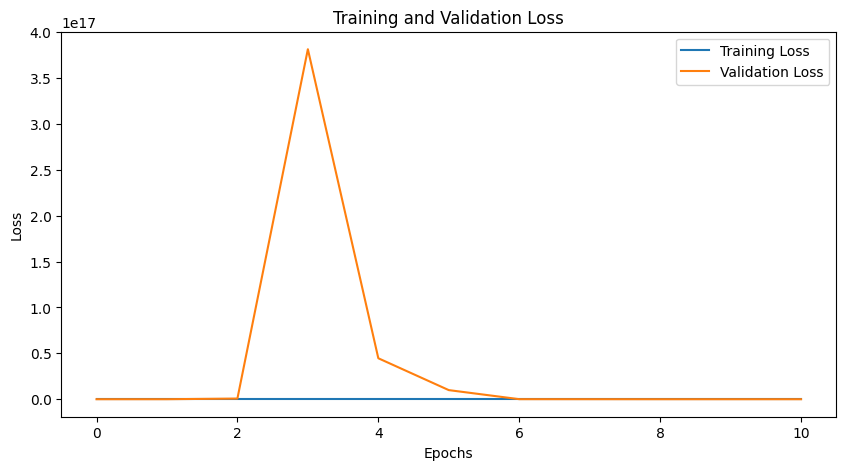

In [18]:
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=150,
    lr=0.001
)

### Evaluating

In [ ]:
from joblib import load

model = load('models/svr_model.joblib')
scaler = load('models/scaler.joblib')

# Example usage:
X_test_scaled = scaler.transform(X_test)

# Evaluate
test_pred = model.predict(X_test)

In [20]:
import torch

def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(device)
            numeric = batch['predicted'].to(device)
            targets = batch['observed'].cpu().numpy()
            
            outputs = model(images, numeric).cpu().numpy()
            
            predictions.extend(outputs.squeeze())
            actuals.extend(targets.squeeze())
    
    return predictions, actuals

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MobileV4WithNumeric(1)

model.to(device)
model.load_state_dict(torch.load(f'models/{modelName}.pt'))

test_dataset = ImageNumericDataset(image_dir='data/counted_images', csv_path='results/Fit_to_observed_CerealNet_VGG16.csv')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
test_pred, y_test = evaluate_model(model, test_loader)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from permetrics.regression import RegressionMetric

rmse  = np.sqrt(mean_squared_error(y_test, test_pred))
print(f"RMSE: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test, test_pred)
print(f"MAE: {mae}")

# Convert lists to NumPy arrays for element-wise operations
y_test_array = np.array(y_test)
test_pred_array = np.array(test_pred)

# Calculate MAPE
mape = np.mean(np.abs((y_test_array - test_pred_array) / y_test_array)) * 100
print(f"MAPE: {mape} %")

# Calculate KGE (Kling-Gupta Efficiency)
evaluator = RegressionMetric(y_test, test_pred)
kge = evaluator.kling_gupta_efficiency()
print(f"KGE: {kge}")

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.savefig('predictions_vs_actuals.png')
plt.show()